In [30]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
images = pd.read_csv('data/CUB/images.txt', sep=' ', header=None, names=['image_id', 'file_path'])
split = pd.read_csv('data/CUB/train_test_split.txt', sep=' ', header=None, names=['image_id', 'is_training'])
classes = pd.read_csv('data/CUB/image_class_labels.txt', sep=' ', header=None, names=['image_id', 'class_id'])

In [6]:
metadata = images.merge(split, on='image_id').merge(classes, on='image_id')

In [ ]:
col_names = ['image_id', 'attribute_id', 'is_present', 'certainty_id', 'time', 'extra']

img_attrs = pd.read_csv('data/CUB/attributes/image_attribute_labels.txt', 
                        sep=r'\s+',  
                        header=None, 
                        names=col_names)

img_attrs = img_attrs[['image_id', 'attribute_id', 'is_present', 'certainty_id']]

   image_id  attribute_id  is_present  certainty_id
0         1             1           0             3
1         1             2           0             3
2         1             3           0             3
3         1             4           0             3
4         1             5           1             3

Udało się! Kształt macierzy to: (11788, 312)


In [13]:
attr_matrix = img_attrs.pivot(index='image_id', columns='attribute_id', values='is_present').fillna(0)

In [15]:
df_final = metadata.merge(attr_matrix, on='image_id')

In [18]:
df_final

,image_id,file_path,is_training,class_id,1,2,3,4,5,6,...,303,304,305,306,307,308,309,310,311,312
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,0,0,0,0,1,0,...,0,0,0,1,0,0,1,0,0,0
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11783,11784,200.Common_Yellowthroat/Common_Yellowthroat_00...,1,200,0,1,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
11784,11785,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,200,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
11785,11786,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,200,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
11786,11787,200.Common_Yellowthroat/Common_Yellowthroat_00...,1,200,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


#### Sprawdzenie empirycznych atrybutów

In [19]:
attributes_df = pd.read_csv('data/CUB/attributes.txt', sep=r'\s+', header=None, names=['attr_id', 'attr_name'])

attr_mapping = dict(zip(attributes_df['attr_id'], attributes_df['attr_name']))

In [29]:
sum_A = attr_matrix.sum(axis=0)
co_occurrence = attr_matrix.T.dot(attr_matrix)

p_B_given_A = co_occurrence.divide(sum_A, axis=0)

np.fill_diagonal(p_B_given_A.values, 0)

threshold = 0.9
strong_relations = np.where(p_B_given_A >= threshold)

print(f"Znaleziono {len(strong_relations[0])} silnych relacji (P > {threshold}):\n")

for a, b in zip(strong_relations[0], strong_relations[1]):
    attr_a_id = attr_matrix.columns[a] 
    attr_b_id = attr_matrix.columns[b]

    name_a = attr_mapping.get(int(attr_a_id), f"Unknown_{attr_a_id}")
    name_b = attr_mapping.get(int(attr_b_id), f"Unknown_{attr_b_id}")

    prob = p_B_given_A.iloc[a, b]

    print(f"{name_a}  -->  {name_b} (Prawdopodobieństwo: {prob:.2f})")

Znaleziono 30 silnych relacji (P > 0.9):

has_bill_shape::cone  -->  has_bill_length::shorter_than_head (Prawdopodobieństwo: 0.95)
has_wing_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.93)
has_wing_color::olive  -->  has_eye_color::black (Prawdopodobieństwo: 0.91)
has_upperparts_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.93)
has_upperparts_color::olive  -->  has_eye_color::black (Prawdopodobieństwo: 0.92)
has_underparts_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.94)
has_underparts_color::yellow  -->  has_belly_color::yellow (Prawdopodobieństwo: 0.90)
has_underparts_color::white  -->  has_belly_color::white (Prawdopodobieństwo: 0.91)
has_back_color::brown  -->  has_upperparts_color::brown (Prawdopodobieństwo: 0.91)
has_back_color::yellow  -->  has_eye_color::black (Prawdopodobieństwo: 0.90)
has_back_color::olive  -->  has_eye_color::black (Prawdopodobieństwo: 0.92)
has_back_color::black  -->  has_upperparts_color::black (Prawd

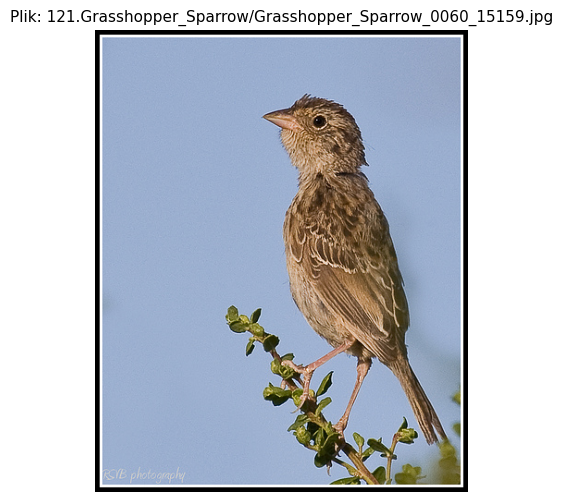

--- Znaleziono 35 aktywnych atrybutów dla tego zdjęcia: ---
✅ has_bill_shape::all-purpose
✅ has_wing_color::grey
✅ has_wing_color::buff
✅ has_upperparts_color::grey
✅ has_upperparts_color::buff
✅ has_underparts_color::grey
✅ has_underparts_color::buff
✅ has_breast_pattern::multi-colored
✅ has_back_color::grey
✅ has_back_color::buff
✅ has_tail_shape::pointed_tail
✅ has_upper_tail_color::buff
✅ has_head_pattern::malar
✅ has_breast_color::buff
✅ has_throat_color::grey
✅ has_throat_color::buff
✅ has_eye_color::black
✅ has_bill_length::shorter_than_head
✅ has_forehead_color::grey
✅ has_forehead_color::buff
✅ has_under_tail_color::grey
✅ has_nape_color::brown
✅ has_nape_color::grey
✅ has_belly_color::grey
✅ has_wing_shape::pointed-wings
✅ has_size::small_(5_-_9_in)
✅ has_shape::pigeon-like
✅ has_back_pattern::striped
✅ has_tail_pattern::multi-colored
✅ has_belly_pattern::striped
✅ has_primary_color::buff
✅ has_leg_color::buff
✅ has_bill_color::buff
✅ has_crown_color::buff
✅ has_wing_pattern:

In [31]:
base_image_dir = 'data/CUB/images/' 

sample_row = df_final.sample(1).iloc[0]

file_path = sample_row['file_path']
full_path = os.path.join(base_image_dir, file_path)

metadata_cols = ['image_id', 'file_path', 'is_training', 'class_id']
active_attributes = []

for col_name in df_final.columns:
    if col_name not in metadata_cols:
        if sample_row[col_name] == 1.0:
            human_readable_name = attr_mapping.get(int(col_name), f"Atrybut_{col_name}")
            active_attributes.append(human_readable_name)
img = Image.open(full_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Plik: {file_path}", fontsize=11)
plt.show()
print(f"--- Znaleziono {len(active_attributes)} aktywnych atrybutów dla tego zdjęcia: ---")
for attr in active_attributes:
    print(f"✅ {attr}")